# Sheffield Shield Tactical Post-Match Review  
**South Australia vs Queensland — 20–23 October 2024**  

This notebook presents a single-match tactical review of the Sheffield Shield fixture between South Australia and Queensland.  
The analysis focuses on phase-level scoring patterns, spell impact, pressure creation, and batting contributions that shaped the match outcome.

## Objective
- Identify how the match evolved across innings phases  
- Isolate the most influential bowling spell in the match  
- Assess the batting contributions that created or resisted scoreboard pressure  
- Translate ball-by-ball data into coach- and analyst-relevant insights

## Data Notes
- Source data: ball-by-ball match data  
- Analysis restricted to `match_id = 1444496`  
- Dismissal information was manually enriched for the analysed match only


In [109]:
import pandas as pd
import numpy as np

df = pd.read_csv(
    "../data/processed/sheffield_shield_ball_by_ball.csv"
)
match_df = df[
    (df["match_id"] == 1444496)
].copy()

match_df["is_dot"] = (match_df["runs_total"] == 0).astype(int)
match_df["is_boundary"] = match_df["runs_batter"].isin([4, 6]).astype(int)

match_df = match_df.sort_values(
    ["innings", "over", "ball_in_over"]
).reset_index(drop=True)

match_df["wickets_last_15"] = (
    match_df
    .groupby("innings")["is_wicket"]
    .rolling(window=15, min_periods=1)
    .sum()
    .reset_index(level=0, drop=True)
)

match_df["partnership_id"] = (
    match_df.groupby("innings")["is_wicket"].cumsum()
)

# Identify the two teams in this match
teams = match_df["batting_team"].unique()

team_a = teams[0]
team_b = teams[1]

# Derive bowling team
match_df["bowling_team"] = np.where(
    match_df["batting_team"] == team_a,
    team_b,
    team_a
)


match_df.head(1)

/var/folders/vx/0hn39_rd5_g696zcwndcqdx80000gn/T/ipykernel_38097/1357697089.py:4: DtypeWarning: Columns (15,16,17,18) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


,match_id,season,venue,dates,innings,batting_team,over,ball_in_over,batter,bowler,...,is_wicket,dismissed_batter,dismissal type,wicket_bowler,fielder,is_dot,is_boundary,wickets_last_15,partnership_id,bowling_team
0,1444496,2024/25,"Allan Border Field, Brisbane","2024-10-20,2024-10-21,2024-10-22,2024-10-23",1,South Australia,0,1,HJ Hunt,MG Neser,...,0.0,NaN,NaN,NaN,NaN,0,1,0.0,0.0,Queensland


## Phase Analysis Setup

The innings are split into three broad phases to capture how scoring tempo and pressure changed over time:

- **1–20 overs**: new-ball phase  
- **21–50 overs**: middle overs / consolidation phase  
- **51+ overs**: later-innings / fatigue phase


In [110]:
def assign_phase(over):
    if over <= 20:
        return "1-20"
    elif over <= 50:
        return "21-50"
    else:
        return "51+"

match_df["phase"] = match_df["over"].apply(assign_phase)

In [111]:
phase_summary = (
    match_df
    .groupby(["innings", "batting_team", "phase"])
    .agg(
        runs=("runs_total", "sum"),
        balls=("ball_in_over", "count"),
        wickets=("is_wicket", "sum"),
        dots=("runs_total", lambda x: (x == 0).sum())
    )
    .reset_index()
)

phase_summary["run_rate"] = phase_summary["runs"] / (phase_summary["balls"] / 6)
phase_summary["dot_pct"] = phase_summary["dots"] / phase_summary["balls"]

phase_summary.sort_values(["innings", "phase"])

,innings,batting_team,phase,runs,balls,wickets,dots,run_rate,dot_pct
0,1,South Australia,1-20,43,126,0.0,102,2.047619,0.809524
1,1,South Australia,21-50,97,180,1.0,133,3.233333,0.738889
2,1,South Australia,51+,174,299,9.0,217,3.491639,0.725753
3,2,Queensland,1-20,74,133,4.0,102,3.338346,0.766917
4,2,Queensland,21-50,122,184,2.0,128,3.978261,0.695652
5,2,Queensland,51+,112,132,3.0,79,5.090909,0.598485
6,3,South Australia,1-20,75,126,2.0,99,3.571429,0.785714
7,3,South Australia,21-50,100,180,2.0,139,3.333333,0.772222
8,3,South Australia,51+,177,262,5.0,171,4.053435,0.652672
9,4,Queensland,1-20,67,126,1.0,95,3.190476,0.753968


## Run Rate by Phase

This chart compares run rate across the three phases for each innings, helping identify where scoring accelerated or flattened.


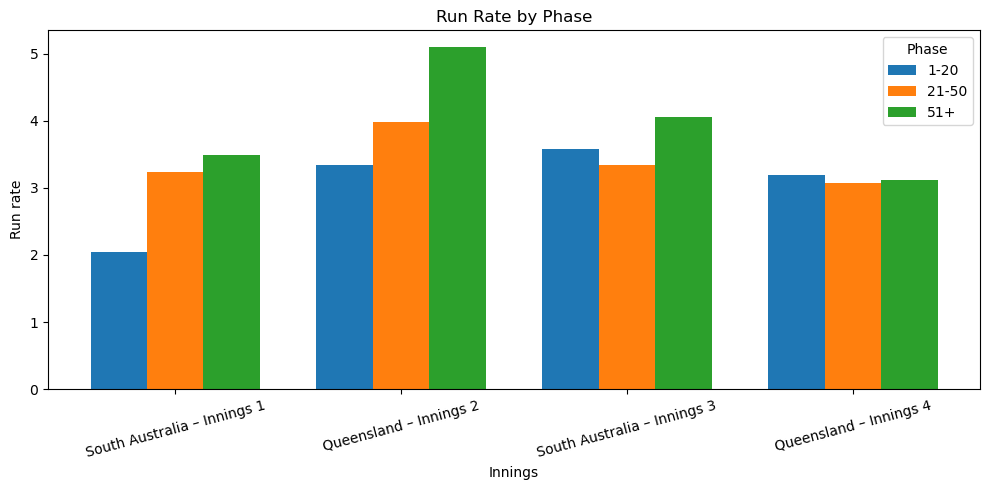

In [114]:
import numpy as np
import matplotlib.pyplot as plt

# Use existing phase_summary
phase_plot = phase_summary.copy()

# Ensure consistent phase order
phase_order = ["1-20", "21-50", "51+"]
phase_plot["phase"] = pd.Categorical(
    phase_plot["phase"],
    categories=phase_order,
    ordered=True
)

# Pivot from existing summary table
pivot = (
    phase_plot
    .pivot(index=["innings", "batting_team"], columns="phase", values="run_rate")
    .reindex(columns=phase_order)
)

x = np.arange(len(pivot))
bar_width = 0.25

plt.figure(figsize=(10, 5))

colors = {
    "1-20": "#1f77b4",
    "21-50": "#ff7f0e",
    "51+": "#2ca02c"
}

for i, phase in enumerate(phase_order):
    plt.bar(
        x + i * bar_width,
        pivot[phase],
        width=bar_width,
        label=phase,
        color=colors[phase]
    )

labels = [
    f"{team} – Innings {inn}"
    for inn, team in pivot.index
]

plt.xticks(x + bar_width, labels, rotation=15)
plt.xlabel("Innings")
plt.ylabel("Run rate")
plt.title("Run Rate by Phase")
plt.legend(title="Phase")
plt.tight_layout()
plt.show()

## Dot-Ball Pressure by Phase

Dot-ball percentage is used here as the primary pressure indicator. Higher dot-ball rates generally reflect stronger bowling control and reduced strike rotation.


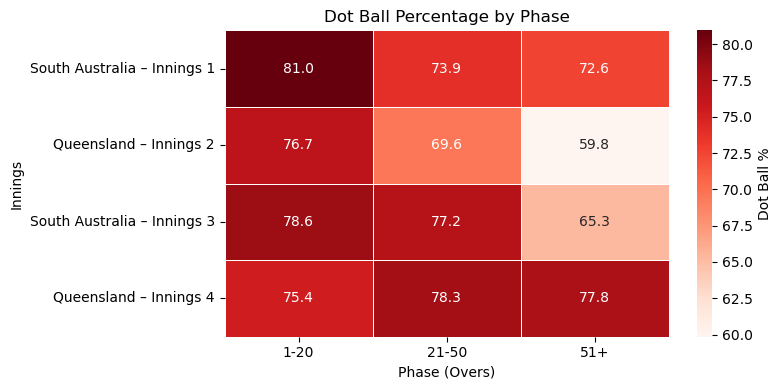

In [115]:
# Use existing phase_summary
phase_dot = phase_summary.copy()

# Create label
phase_dot["label"] = (
    phase_dot["batting_team"] + " – Innings " + phase_dot["innings"].astype(str)
)

# Force innings order 1 → 4
innings_order = sorted(phase_dot["innings"].unique())
label_order = []

for inn in innings_order:
    row = phase_dot[phase_dot["innings"] == inn].iloc[0]
    label_order.append(f"{row['batting_team']} – Innings {inn}")

# Pivot directly from phase_summary
heatmap_data = (
    phase_dot.pivot(index="label", columns="phase", values="dot_pct")
    .reindex(label_order)
    .reindex(columns=["1-20", "21-50", "51+"])
)

# Convert to percentage for display
heatmap_display = heatmap_data * 100

plt.figure(figsize=(8, 4))

sns.heatmap(
    heatmap_display,
    annot=True,
    fmt=".1f",
    cmap="Reds",
    linewidths=0.5,
    cbar_kws={"label": "Dot Ball %"}
)

plt.title("Dot Ball Percentage by Phase")
plt.xlabel("Phase (Overs)")
plt.ylabel("Innings")
plt.tight_layout()
plt.show()

## Spell Impact Analysis

Bowling spells are identified as continuous overs by the same bowler, separated by at least one over bowled by another bowler.  
Spells are then ranked using a simple impact model that rewards wicket-taking, economy, and dot-ball pressure.


In [ ]:
# Summarise each over by bowler
over_bowler = (
    match_df
    .groupby(["innings", "bowler", "over"])
    .agg(
        runs=("runs_total", "sum"),
        wickets=("is_wicket", "sum"),
        balls=("ball_in_over", "count"),
        dots=("runs_total", lambda x: (x == 0).sum())
    )
    .reset_index()
)

over_bowler["dot_pct"] = over_bowler["dots"] / over_bowler["balls"]

,innings,bowler,over,runs,wickets,balls,dots,dot_pct
15,1,MG Neser,0,4,0.0,6,5,0.833333
58,1,MT Steketee,1,0,0.0,6,6,1.000000
16,1,MG Neser,2,2,0.0,6,5,0.833333
59,1,MT Steketee,3,3,0.0,6,4,0.666667
17,1,MG Neser,4,4,0.0,6,3,0.500000


In [85]:
over_bowler = over_bowler.sort_values(["innings", "bowler", "over"])

# Identify spell breaks
over_bowler["prev_over"] = over_bowler.groupby(["innings", "bowler"])["over"].shift(1)

over_bowler["new_spell"] = (
    (over_bowler["prev_over"].isna()) |
    (over_bowler["over"] - over_bowler["prev_over"] > 2)
)

# Create spell ID
over_bowler["spell_id"] = over_bowler.groupby(["innings", "bowler"])["new_spell"].cumsum()

over_bowler.head(10)

,innings,bowler,over,runs,wickets,balls,dots,dot_pct,prev_over,new_spell,spell_id
0,1,J Clayton,52,1,0.0,6,5,0.833333,NaN,True,1
1,1,J Clayton,54,4,0.0,6,2,0.333333,52.0,False,1
2,1,M Labuschagne,14,1,0.0,6,5,0.833333,NaN,True,1
3,1,M Labuschagne,16,0,0.0,6,6,1.000000,14.0,False,1
4,1,M Labuschagne,18,1,0.0,6,5,0.833333,16.0,False,1
5,1,M Labuschagne,27,4,0.0,6,4,0.666667,18.0,True,2
6,1,M Labuschagne,45,1,0.0,6,5,0.833333,27.0,True,3
7,1,M Labuschagne,47,7,0.0,6,3,0.500000,45.0,False,3
8,1,M Labuschagne,49,3,0.0,6,4,0.666667,47.0,False,3
9,1,M Labuschagne,66,4,0.0,6,3,0.500000,49.0,True,4


In [86]:
spell_summary = (
    over_bowler
    .groupby(["innings", "bowler", "spell_id"])
    .agg(
        start_over=("over", "min"),
        end_over=("over", "max"),
        overs=("over", "nunique"),
        runs=("runs", "sum"),
        wickets=("wickets", "sum"),
        balls=("balls", "sum"),
        dot_pct=("dot_pct", "mean")
    )
    .reset_index()
)

spell_summary["economy"] = spell_summary["runs"] / spell_summary["overs"]
spell_summary = spell_summary[spell_summary["overs"] >= 4].copy()
spell_summary["impact_score"] = (
    spell_summary["wickets"] * 2
    - spell_summary["economy"]
    + spell_summary["dot_pct"] * 2
)
spell_summary["batting_team"] = spell_summary["innings"].map(
    match_df.groupby("innings")["batting_team"].first())


spell_summary.sort_values("impact_score", ascending=False).head(10)

,innings,bowler,spell_id,start_over,end_over,overs,runs,wickets,balls,dot_pct,economy,impact_score,batting_team
80,4,N McAndrew,2,18,30,7,19,3.0,42,0.857143,2.714286,5.000000,Queensland
27,1,T Whitney,4,87,99,7,19,3.0,42,0.785714,2.714286,4.857143,South Australia
39,2,N McAndrew,1,1,11,6,13,2.0,36,0.861111,2.166667,3.555556,Queensland
23,1,MT Steketee,6,80,90,6,15,2.0,36,0.833333,2.500000,3.166667,South Australia
65,3,MT Steketee,4,81,93,7,37,3.0,43,0.700680,5.285714,2.115646,South Australia
26,1,T Whitney,3,56,64,5,17,2.0,30,0.733333,3.400000,2.066667,South Australia
67,3,T Whitney,2,31,39,5,19,2.0,30,0.766667,3.800000,1.733333,South Australia
53,3,MG Neser,1,0,10,6,12,1.0,36,0.833333,2.000000,1.666667,South Australia
76,4,L Scott,1,19,33,8,17,1.0,48,0.875000,2.125000,1.625000,Queensland
75,4,JS Buckingham,4,59,69,6,14,1.0,36,0.805556,2.333333,1.277778,Queensland


## Match-Defining Spell: N. McAndrew (4th Innings)

The highest-ranked spell is examined in more detail to understand how pressure was applied and how it translated into wickets.


In [87]:
# Filter to McAndrew in innings 4
mcandrew_4 = match_df[
    (match_df["bowler"] == "N McAndrew") &
    (match_df["innings"] == 4)
]

mcandrew_4.groupby("batter").agg(
    balls=("ball_in_over", "count"),
    runs=("runs_total", "sum"),
    dots=("runs_total", lambda x: (x == 0).sum()),
    wickets=("is_wicket", "sum")
).reset_index()


,batter,balls,runs,dots,wickets
0,BR McDermott,2,0,2,1.0
1,J Clayton,8,2,6,0.0
2,JJ Peirson,4,0,4,1.0
3,LD Hearne,27,16,23,0.0
4,M Labuschagne,20,10,17,1.0
5,MT Renshaw,27,5,25,1.0
6,MT Steketee,12,4,11,1.0
7,T Whitney,2,0,2,0.0
8,UT Khawaja,6,1,5,0.0


In [88]:
# Filter McAndrew spell overs (18–30, innings 4)
mc_spell = match_df[
    (match_df["innings"] == 4) &
    (match_df["bowler"] == "N McAndrew") &
    (match_df["over"] >= 18) &
    (match_df["over"] <= 30)
].copy()

# Compute batter-level breakdown
deep_matchup = (
    mc_spell.groupby("batter")
    .agg(
        balls=("ball_in_over", "count"),
        runs=("runs_total", "sum"),
        dots=("runs_total", lambda x: (x == 0).sum()),
        boundaries=("runs_total", lambda x: ((x == 4) | (x == 6)).sum()),
        singles=("runs_total", lambda x: (x == 1).sum()),
        doubles=("runs_total", lambda x: (x == 2).sum()),
        wickets=("is_wicket", "sum")
    )
    .reset_index()
)

deep_matchup["dot_pct"] = deep_matchup["dots"] / deep_matchup["balls"]
deep_matchup["boundary_pct"] = deep_matchup["boundaries"] / deep_matchup["balls"]
deep_matchup["single_pct"] = deep_matchup["singles"] / deep_matchup["balls"]
deep_matchup["double_pct"] = deep_matchup["doubles"] / deep_matchup["balls"]

deep_matchup.sort_values("balls", ascending=False)

,batter,balls,runs,dots,boundaries,singles,doubles,wickets,dot_pct,boundary_pct,single_pct,double_pct
3,M Labuschagne,20,10,17,2,0,1,1.0,0.850000,0.100000,0.000000,0.05
2,LD Hearne,14,8,12,2,0,0,0.0,0.857143,0.142857,0.000000,0.00
1,J Clayton,3,1,2,0,1,0,0.0,0.666667,0.000000,0.333333,0.00
4,MT Renshaw,3,0,3,0,0,0,1.0,1.000000,0.000000,0.000000,0.00
0,BR McDermott,2,0,2,0,0,0,1.0,1.000000,0.000000,0.000000,0.00


## Batting Impact Analysis

Batting impact is assessed using a composite framework rather than raw runs alone.  
The model incorporates:
- proportion of team runs
- runs scored during collapse windows
- dot-ball control
- partnership contribution

This helps identify innings that shaped match structure rather than simply rewarding volume scoring.


In [91]:
bat_impact = (
    match_df
    .groupby(["innings", "batting_team", "batter"])
    .agg(
        runs=("runs_batter", "sum"),
        balls=("ball_in_over", "count"),
        dots=("is_dot", "sum"),
        boundaries=("is_boundary", "sum")
    )
    .reset_index()
)

bat_impact["strike_rate"] = (bat_impact["runs"] / bat_impact["balls"]) * 100
bat_impact["dot_pct"] = bat_impact["dots"] / bat_impact["balls"]

In [92]:
team_totals = (
    match_df
    .groupby(["innings", "batting_team"])
    .agg(team_runs=("runs_batter", "sum"))
    .reset_index()
)

bat_impact = bat_impact.merge(
    team_totals,
    on=["innings", "batting_team"],
    how="left"
)

bat_impact["team_run_pct"] = bat_impact["runs"] / bat_impact["team_runs"]

In [93]:
match_df["collapse_window"] = match_df["wickets_last_15"] >= 2

In [94]:
collapse_runs = (
    match_df[match_df["collapse_window"]]
    .groupby(["innings", "batter"])
    .agg(runs_in_collapse=("runs_batter", "sum"))
    .reset_index()
)

bat_impact = bat_impact.merge(
    collapse_runs,
    on=["innings", "batter"],
    how="left"
)

bat_impact["runs_in_collapse"] = bat_impact["runs_in_collapse"].fillna(0)

In [95]:
partnership_runs = (
    match_df
    .groupby(["innings", "partnership_id", "batter"])
    .agg(partnership_runs=("runs_batter", "sum"))
    .reset_index()
)

max_partnership = (
    partnership_runs
    .groupby(["innings", "batter"])
    .agg(max_partnership_runs=("partnership_runs", "max"))
    .reset_index()
)

bat_impact = bat_impact.merge(
    max_partnership,
    on=["innings", "batter"],
    how="left"
)

In [96]:
bat_impact["norm_team_pct"] = bat_impact["team_run_pct"] / bat_impact["team_run_pct"].max()
bat_impact["norm_collapse"] = bat_impact["runs_in_collapse"] / (bat_impact["runs_in_collapse"].max() + 1)
bat_impact["norm_dot"] = 1 - bat_impact["dot_pct"]  # lower dots = better
bat_impact["norm_partnership"] = bat_impact["max_partnership_runs"] / (bat_impact["max_partnership_runs"].max() + 1)

bat_impact["impact_score"] = (
    0.4 * bat_impact["norm_team_pct"]
    + 0.3 * bat_impact["norm_collapse"]
    + 0.2 * bat_impact["norm_dot"]
    + 0.1 * bat_impact["norm_partnership"]
)

## Batting Impact Ranking

The table below highlights the most structurally significant batting contributions in the match.


In [98]:
bat_impact[
    [
        "innings",
        "batting_team",
        "batter",
        "runs",
        "balls",
        "strike_rate",
        "dot_pct",
        "team_run_pct",
        "runs_in_collapse",
        "max_partnership_runs",
        "impact_score",
    ]
].sort_values("impact_score", ascending=False).head(10)

,innings,batting_team,batter,runs,balls,strike_rate,dot_pct,team_run_pct,runs_in_collapse,max_partnership_runs,impact_score
22,3,South Australia,AT Carey,123,166,74.096386,0.626506,0.361765,8.0,40,0.671381
4,1,South Australia,HJ Hunt,136,314,43.312102,0.777070,0.441558,1.0,54,0.562689
11,2,Queensland,BR McDermott,52,99,52.525253,0.747475,0.184397,11.0,33,0.549444
34,4,Queensland,J Clayton,91,164,55.487805,0.737805,0.408072,0.0,57,0.520380
13,2,Queensland,JJ Peirson,94,119,78.991597,0.605042,0.333333,0.0,55,0.475780
36,4,Queensland,LD Hearne,44,82,53.658537,0.768293,0.197309,4.0,44,0.400943
7,1,South Australia,L Scott,9,8,112.500000,0.625000,0.029221,9.0,9,0.341988
0,1,South Australia,AT Carey,42,63,66.666667,0.682540,0.136364,2.0,42,0.309435
31,3,South Australia,NA McSweeney,72,130,55.384615,0.784615,0.211765,0.0,34,0.293532
2,1,South Australia,CJ McInerney,51,108,47.222222,0.768519,0.165584,0.0,51,0.284227


## Bowler Matchups — A.T. Carey

This section examines how Carey managed different bowlers during his 3rd-innings 123*, with a focus on control, strike rotation, and selective acceleration.


In [99]:
# --- Carey vs bowlers (Innings 3) ---
carey_balls = match_df[
    (match_df["innings"] == 3) &
    (match_df["batter"] == "AT Carey")
].copy()

carey_vs_bowlers = (
    carey_balls.groupby("bowler")
    .agg(
        balls=("ball_in_over", "count"),
        runs=("runs_total", "sum"),
        dots=("runs_total", lambda x: (x == 0).sum()),
        boundaries=("runs_total", lambda x: ((x == 4) | (x == 6)).sum()),
        singles=("runs_total", lambda x: (x == 1).sum()),
        doubles=("runs_total", lambda x: (x == 2).sum()),
        wickets=("is_wicket", "sum")
    )
    .reset_index()
)

carey_vs_bowlers["dot_pct"] = carey_vs_bowlers["dots"] / carey_vs_bowlers["balls"]
carey_vs_bowlers["boundary_pct"] = carey_vs_bowlers["boundaries"] / carey_vs_bowlers["balls"]
carey_vs_bowlers["single_pct"] = carey_vs_bowlers["singles"] / carey_vs_bowlers["balls"]
carey_vs_bowlers["double_pct"] = carey_vs_bowlers["doubles"] / carey_vs_bowlers["balls"]

carey_vs_bowlers.sort_values("balls", ascending=False)

,bowler,balls,runs,dots,boundaries,singles,doubles,wickets,dot_pct,boundary_pct,single_pct,double_pct
4,MT Steketee,49,48,33,8,6,2,0.0,0.673469,0.163265,0.122449,0.040816
2,MJ Swepson,44,23,30,2,11,1,0.0,0.681818,0.045455,0.250000,0.022727
0,M Labuschagne,30,23,19,4,7,0,0.0,0.633333,0.133333,0.233333,0.000000
1,MG Neser,21,11,13,1,7,0,0.0,0.619048,0.047619,0.333333,0.000000
3,MT Renshaw,12,7,5,0,7,0,0.0,0.416667,0.000000,0.583333,0.000000
5,T Whitney,10,15,4,3,3,0,0.0,0.400000,0.300000,0.300000,0.000000


## Bowler Matchups — H.J. Hunt

This section profiles Hunt's first-innings matchups, highlighting the degree of pressure absorbed during his platform-setting innings.


In [100]:
# --- Hunt vs bowlers (Innings 1) ---
hunt_balls = match_df[
    (match_df["innings"] == 1) &
    (match_df["batter"] == "HJ Hunt")
].copy()

hunt_vs_bowlers = (
    hunt_balls.groupby("bowler")
    .agg(
        balls=("ball_in_over", "count"),
        runs=("runs_total", "sum"),
        dots=("runs_total", lambda x: (x == 0).sum()),
        boundaries=("runs_total", lambda x: ((x == 4) | (x == 6)).sum()),
        singles=("runs_total", lambda x: (x == 1).sum()),
        doubles=("runs_total", lambda x: (x == 2).sum()),
        wickets=("is_wicket", "sum")
    )
    .reset_index()
)

hunt_vs_bowlers["dot_pct"] = hunt_vs_bowlers["dots"] / hunt_vs_bowlers["balls"]
hunt_vs_bowlers["boundary_pct"] = hunt_vs_bowlers["boundaries"] / hunt_vs_bowlers["balls"]
hunt_vs_bowlers["single_pct"] = hunt_vs_bowlers["singles"] / hunt_vs_bowlers["balls"]
hunt_vs_bowlers["double_pct"] = hunt_vs_bowlers["doubles"] / hunt_vs_bowlers["balls"]

hunt_vs_bowlers.sort_values("balls", ascending=False)

,bowler,balls,runs,dots,boundaries,singles,doubles,wickets,dot_pct,boundary_pct,single_pct,double_pct
2,MG Neser,79,26,64,2,8,5,1.0,0.810127,0.025316,0.101266,0.063291
6,T Whitney,66,29,54,4,4,3,0.0,0.818182,0.060606,0.060606,0.045455
3,MJ Swepson,60,31,45,4,9,2,0.0,0.750000,0.066667,0.150000,0.033333
5,MT Steketee,59,31,47,5,4,2,0.0,0.796610,0.084746,0.067797,0.033898
1,M Labuschagne,37,12,28,0,7,1,0.0,0.756757,0.000000,0.189189,0.027027
4,MT Renshaw,7,5,3,0,3,1,0.0,0.428571,0.000000,0.428571,0.142857
0,J Clayton,6,3,3,0,3,0,0.0,0.500000,0.000000,0.500000,0.000000


## Key Match Insights

- South Australia's structural advantage was built through stable batting contributions in innings 1 and 3.  
- Queensland remained competitive through innings 2, but could not sustain similar control in the 4th innings chase.  
- Nathan McAndrew's 4th-innings spell was the match-defining bowling intervention.  
- Alex Carey's 123* was the most influential batting contribution in the match context.
